# Naive Bayes on NASA Exoplanet Archive data

This Colab notebook shows a full **master-level workflow** for downloading confirmed exoplanet data from the **NASA Exoplanet Archive**, preparing features, defining a supervised target, training a **Gaussian Naive Bayes** classifier, and evaluating the results.

## What this notebook does

We use the **Planetary Systems Composite Parameters** table (`pscomppars`), which provides one row per confirmed planet and is intended for statistical studies. The Archive documents that `pscomppars` is a more filled-in table with one row per planet, but it may combine values from multiple references, so it is convenient for demographics but not always fully self-consistent. The Archive also recommends using the TAP service for current programmatic access.

In this demo, the default target is:

`is_transit = 1 if discoverymethod == 'Transit' else 0`

That target is useful for learning the method, but it is **not** a deep physical class: it reflects observational selection effects as well as planet properties. After you get the workflow running, you can replace the target with a more science-driven label.

## Data source

This notebook queries the NASA Exoplanet Archive TAP service, which supports access to `ps` and `pscomppars`, and the `pscomppars` table is documented as the statistical one-row-per-planet table. See the official Archive documentation for details.

Official references:
- TAP guide: https://exoplanetarchive.ipac.caltech.edu/docs/TAP/usingTAP.html
- PS/PSCompPars table definitions: https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html
- About `pscomppars`: https://exoplanetarchive.ipac.caltech.edu/docs/pscp_about.html

## My work:

After running the baseline notebook, I:
1. replaced the target with a physical label,
2. compared Gaussian Naive Bayes with Logistic Regression,
3. used balanced metrics for imbalanced classes,
4. checking feature correlations and discussing why Naive Bayes can still work despite violated independence assumptions.


## 1. Install and import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
)


## 2. Download data from the NASA Exoplanet Archive

We query the **TAP** endpoint with a SQL-like ADQL statement. The `pscomppars` table gives one row per confirmed planet and is commonly used for demographic analyses.

We intentionally request a compact subset of columns that are convenient for a first supervised-learning exercise.

In [2]:
# TAP sync endpoint
base_url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

# A compact query for confirmed planets from pscomppars
query = r"""
select
    pl_name,
    hostname,
    discoverymethod,
    pl_orbper,
    pl_orbsmax,
    pl_rade,
    pl_bmasse,
    pl_dens,
    pl_orbeccen,
    pl_eqt,
    pl_insol,
    st_teff,
    st_rad,
    st_mass,
    st_met,
    st_logg,
    sy_dist,
    sy_snum,
    sy_pnum
from pscomppars
"""

import urllib.parse

url = f"{base_url}?query={urllib.parse.quote(query)}&format=csv"
df = pd.read_csv(url)

print(df.shape)
df.head()

(6150, 19)


,pl_name,hostname,discoverymethod,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,pl_insol,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum
0,Kepler-1167 b,Kepler-1167,Transit,1.003934,0.01750,1.710000,3.570,3.92,0.0,1419.0,1039.697,4971.0,0.750,0.790,-0.05,4.600,820.905,1,1
1,Kepler-1740 b,Kepler-1740,Transit,8.172400,0.07790,3.323214,11.000,1.65,0.0,858.0,127.950,5705.0,0.905,0.943,-0.06,4.499,1061.770,1,1
2,Kepler-1581 b,Kepler-1581,Transit,6.283855,0.06865,0.800000,0.437,4.69,0.0,1108.0,470.862,6022.0,1.230,1.120,0.07,4.310,493.175,1,1
3,Kepler-644 b,Kepler-644,Transit,3.173917,0.04641,3.150000,10.100,1.78,0.0,1655.0,2381.770,6747.0,1.810,1.490,0.08,4.090,1318.050,1,1
4,Kepler-1752 b,Kepler-1752,Transit,56.358501,0.26980,4.540605,18.700,1.10,0.0,419.0,7.290,5446.0,0.821,0.824,-0.20,4.525,962.888,1,1


## 3. Quick inspection

It is always worth checking how much missing data you have and how the classes are distributed.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6150 entries, 0 to 6149
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          6150 non-null   str    
 1   hostname         6150 non-null   str    
 2   discoverymethod  6150 non-null   str    
 3   pl_orbper        5816 non-null   float64
 4   pl_orbsmax       5834 non-null   float64
 5   pl_rade          6100 non-null   float64
 6   pl_bmasse        6119 non-null   float64
 7   pl_dens          6011 non-null   float64
 8   pl_orbeccen      5212 non-null   float64
 9   pl_eqt           4587 non-null   float64
 10  pl_insol         4310 non-null   float64
 11  st_teff          5860 non-null   float64
 12  st_rad           5836 non-null   float64
 13  st_mass          6142 non-null   float64
 14  st_met           5600 non-null   float64
 15  st_logg          5832 non-null   float64
 16  sy_dist          6123 non-null   float64
 17  sy_snum          6150 non

In [4]:
missing_fraction = df.isna().mean().sort_values(ascending=False)
missing_fraction

pl_insol           0.299187
pl_eqt             0.254146
pl_orbeccen        0.152520
st_met             0.089431
pl_orbper          0.054309
st_logg            0.051707
pl_orbsmax         0.051382
st_rad             0.051057
st_teff            0.047154
pl_dens            0.022602
pl_rade            0.008130
pl_bmasse          0.005041
sy_dist            0.004390
st_mass            0.001301
sy_snum            0.000000
pl_name            0.000000
hostname           0.000000
discoverymethod    0.000000
sy_pnum            0.000000
dtype: float64

In [5]:
df['discoverymethod'].value_counts().head(15)

discoverymethod
Transit                          4517
Radial Velocity                  1182
Microlensing                      275
Imaging                            94
Transit Timing Variations          39
Eclipse Timing Variations          17
Orbital Brightness Modulation       9
Pulsar Timing                       8
Astrometry                          6
Pulsation Timing Variations         2
Disk Kinematics                     1
Name: count, dtype: int64

## 4. Define the supervised-learning target

### Default target used here

We define a binary label:

- `1` = discovered by **Transit**
- `0` = discovered by any other method

This target is useful because it is readily available and usually well-populated. It is mainly a **methodological demonstration**. A transit/non-transit label depends strongly on observational biases, so do not over-interpret it as a purely physical class.

Later in the notebook, I show how to switch to a more science-oriented target.

In [6]:
df['is_transit'] = (df['discoverymethod'] == 'Transit').astype(int)
df['is_transit'].value_counts(normalize=True)

is_transit
1    0.734472
0    0.265528
Name: proportion, dtype: float64

## 5. Select features

We choose a set of continuous numeric predictors suitable for **Gaussian Naive Bayes**. The model assumes that each feature is approximately Gaussian within each class and that features are conditionally independent given the class.

These assumptions are not strictly true for exoplanet data, but Gaussian Naive Bayes is still a very good baseline.

In [7]:
feature_cols = [
    'pl_orbper',
    'pl_orbsmax',
    'pl_rade',
    'pl_bmasse',
    'pl_dens',
    'pl_orbeccen',
    'pl_eqt',
    'pl_insol',
    'st_teff',
    'st_rad',
    'st_mass',
    'st_met',
    'st_logg',
    'sy_dist',
    'sy_snum',
    'sy_pnum',
]

X = df[feature_cols].copy()
y = df['is_transit'].copy()

print(X.shape, y.shape)
X.head()

(6150, 16) (6150,)


,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,pl_insol,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum
0,1.003934,0.01750,1.710000,3.570,3.92,0.0,1419.0,1039.697,4971.0,0.750,0.790,-0.05,4.600,820.905,1,1
1,8.172400,0.07790,3.323214,11.000,1.65,0.0,858.0,127.950,5705.0,0.905,0.943,-0.06,4.499,1061.770,1,1
2,6.283855,0.06865,0.800000,0.437,4.69,0.0,1108.0,470.862,6022.0,1.230,1.120,0.07,4.310,493.175,1,1
3,3.173917,0.04641,3.150000,10.100,1.78,0.0,1655.0,2381.770,6747.0,1.810,1.490,0.08,4.090,1318.050,1,1
4,56.358501,0.26980,4.540605,18.700,1.10,0.0,419.0,7.290,5446.0,0.821,0.824,-0.20,4.525,962.888,1,1


## 6. Train/test split

We keep a held-out test set for evaluation. The `stratify=y` argument preserves the class fraction in both the training and test sets.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)

Train shape: (4612, 16)
Test shape : (1538, 16)


## 7. Build the Gaussian Naive Bayes pipeline

Because astronomical catalogues contain missing values, we impute missing numeric entries using the **median**. Then we fit a **GaussianNB** classifier.

For Gaussian Naive Bayes, standardization is not strictly required, because the model estimates class-specific Gaussian parameters for each feature. Median imputation, however, is very useful.

In [9]:
nb_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', GaussianNB()),
])

nb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feat

## 8. Evaluate the classifier

We compute:

- **accuracy**,
- **classification report** with precision, recall, and F1,
- **confusion matrix**,
- **ROC AUC** for a binary problem.

For scientific work, accuracy alone is never enough, especially if the classes are imbalanced.

In [10]:
y_pred = nb_model.predict(X_test)
y_proba = nb_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy: {acc:.4f}')
print(f'ROC AUC : {auc:.4f}')
print()
print(classification_report(y_test, y_pred, digits=4))

Accuracy: 0.8485
ROC AUC : 0.9030

              precision    recall  f1-score   support

           0     0.9487    0.4534    0.6136       408
           1     0.8340    0.9912    0.9058      1130

    accuracy                         0.8485      1538
   macro avg     0.8913    0.7223    0.7597      1538
weighted avg     0.8644    0.8485    0.8283      1538



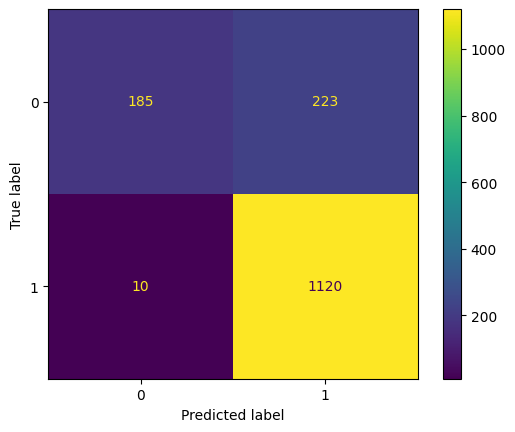

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

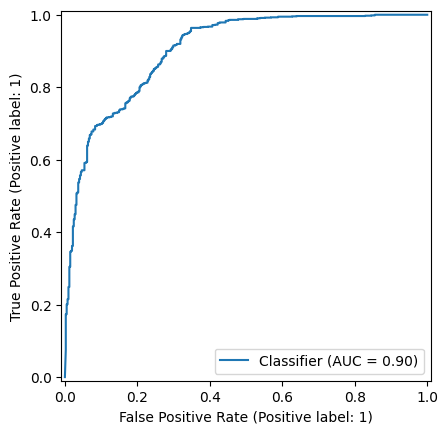

In [12]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()

## 9. Inspect the fitted Gaussian Naive Bayes parameters

A nice feature of Naive Bayes for teaching is interpretability. For each class and each feature, the model estimates a mean and variance.

Inside the pipeline, the fitted `GaussianNB` object is stored under the step name `'clf'`.

In [13]:
gnb = nb_model.named_steps['clf']

means = pd.DataFrame(gnb.theta_, columns=feature_cols, index=['class_0', 'class_1'])
variances = pd.DataFrame(gnb.var_, columns=feature_cols, index=['class_0', 'class_1'])

print('Class priors learned by the model:')
print(gnb.class_prior_)
print()
print('Class-conditional means:')
display(means)
print('Class-conditional variances:')
display(variances)

Class priors learned by the model:
[0.26561145 0.73438855]

Class-conditional means:


,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,pl_insol,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum
class_0,347369.347635,43.673706,9.825555,1168.715562,4.976581,0.16341,810.369167,101.799085,5356.224490,2.676812,0.940487,0.016005,4.218011,980.944971,1.163265,1.800000
class_1,23.681142,0.123371,4.336832,119.550896,4.418440,0.03216,918.980260,402.069743,5388.421107,1.003399,0.933939,0.017343,4.454842,596.856443,1.079421,1.758488


Class-conditional variances:


,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,pl_insol,st_teff,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum
class_0,1.319248e+14,271276.210211,35093.276457,3.296155e+06,35827.476020,35064.304666,99977.566801,5.281255e+04,5.544696e+06,35111.762318,35064.713483,35064.304240,35064.734771,4.571672e+06,35064.437648,35065.628385
class_1,4.202920e+04,35064.292185,35085.319487,2.621803e+05,35660.418557,35064.274263,231768.702100,1.729807e+06,7.071340e+05,35064.443367,35064.336163,35064.294377,35064.323908,2.671356e+05,35064.357129,35065.634013


## 10. Predict on a few examples

This is useful for students because it shows how the classifier turns a feature vector into a probability.

In [14]:
example_idx = X_test.sample(5, random_state=7).index
example_table = df.loc[example_idx, ['pl_name', 'discoverymethod'] + feature_cols].copy()
example_table['true_label'] = y.loc[example_idx].values
example_table['pred_label'] = nb_model.predict(X.loc[example_idx])
example_table['pred_prob_transit'] = nb_model.predict_proba(X.loc[example_idx])[:, 1]
example_table

,pl_name,discoverymethod,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_dens,pl_orbeccen,pl_eqt,pl_insol,...,st_rad,st_mass,st_met,st_logg,sy_dist,sy_snum,sy_pnum,true_label,pred_label,pred_prob_transit
6144,V1298 Tau d,Transit,12.401394,0.10810,6.530000,6.000000,0.120,0.0087,831.0,85.00,...,1.320000,1.100,0.100,4.22700,108.199,3,4,1,1,0.999999
4595,Kepler-1747 b,Transit,6.230320,0.06600,4.265080,16.800000,1.190,0.0000,875.0,138.33,...,0.865000,0.983,0.210,4.55700,1321.380,1,1,1,1,0.999999
2578,EPIC 212499991 b,Transit,34.885000,NaN,1.600000,3.190000,4.280,NaN,NaN,NaN,...,0.757541,0.912,NaN,4.61492,283.290,1,1,1,1,0.999999
5084,TOI-2803 A b,Transit,1.962293,0.03185,18.113713,309.882697,0.287,0.0000,1893.0,2150.00,...,1.245000,1.118,-0.105,4.29800,494.818,2,1,1,1,1.000000
2246,PH2 b,Transit,282.525420,0.83300,9.337081,87.084984,0.580,0.2150,295.1,1.20,...,0.949000,0.966,0.017,4.47000,343.863,1,1,1,1,0.999999


## 11. Switch to a more science-oriented target

Classify whether a planet is **Earth-like** or **Jupiter-like** using the following criteria:

|   | Earth-like | Jupyter-like |
|---|----|---|
|Radius|<2 R_e| > 7 R_e|
|Mass | < 10 M_e | > 50 M_e|



In [23]:
# thresholds
r_elike_max = 2
r_jlike_min = 7

m_elike_max = 10
m_jlike_min = 50

# label assignment function
def assign_labels(df):
    df = df.copy()
    
    has_radius = df['pl_rade'].notna()
    has_mass = df['pl_bmasse'].notna()

    label = pd.Series(-1, index=df.index)

    # radius baseline
    label[has_radius & (df['pl_rade'] <= r_elike_max)] = 1 # 'Earth-like' 
    label[has_radius & (df['pl_rade'] >= r_jlike_min)] = 0 # 'Jupiter-like'

    # mass overrides radius when available
    label[has_mass & (df['pl_bmasse'] <= m_elike_max)] = 1 # 'Earth-like'
    label[has_mass & (df['pl_bmasse'] >= m_jlike_min)] = 0 # 'Jupiter-like'

    # drop ambigous cases
    df['label'] = label

    df_clean = df[df['label'] != -1].reset_index(drop=True)

    return df_clean


# useful features for classification

features_pl_class = [
    'pl_orbper',    # orbital period (days)
    'pl_orbsmax',   # semi-major axis (AU)
    'pl_eqt',       # equilibrium temperature (K)
    'pl_insol',     # insolation flux (S⊕)
    'st_teff',      # stellar effective temperature (K)
    'st_rad',       # stellar radius (R☉)
    'st_mass',      # stellar mass (M☉)
]

df_labeled = assign_labels(df)
print(df_labeled['label'].value_counts())


label
1    3219
0    2109
Name: count, dtype: int64


In [24]:
X2 = df_labeled[features_pl_class].copy()
y2 = df_labeled['label'].copy()

# log-transform features to reduce skew
log_cols = ['pl_orbper', 'pl_orbsmax', 'pl_eqt']

for col in log_cols:
    X2[col] = np.where(X2[col] > 0, np.log(X2[col]), np.nan)

In [25]:
# train a new Naive Bayes model on the labeled data using a K-fold cross-validation pipeline
nb_model_labeled = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', GaussianNB()),
])

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_ovr']    

cv_results = cross_validate(
    estimator=nb_model_labeled,
    X=X2,
    y=y2,
    cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=42) ,
    scoring=metrics,
    return_train_score=False,
    n_jobs=-1,
)

cv_summary = pd.DataFrame({
    metric: cv_results[f'test_{metric}']
    for metric in metrics
})

cv_summary

,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_ovr
0,0.767355,0.810335,0.716780,0.725084,0.806556
1,0.771107,0.807748,0.723154,0.732271,0.817421
2,0.785178,0.820764,0.740109,0.750988,0.836890
3,0.774648,0.821349,0.724012,0.733379,0.829536
4,0.793427,0.837171,0.747481,0.759303,0.835387


In [26]:
y_pred_cv = cross_val_predict(nb_model, X2, y2, cv=cv, method='predict', n_jobs=-1)
y_proba_cv = cross_val_predict(nb_model, X2, y2, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
2
print(classification_report(y2, y_pred_cv, digits=4))
print('Cross-validated ROC AUC:', roc_auc_score(y2, y_proba_cv))

              precision    recall  f1-score   support

           0     0.8932    0.4998    0.6409      2109
           1     0.7457    0.9609    0.8397      3219

    accuracy                         0.7783      5328
   macro avg     0.8194    0.7303    0.7403      5328
weighted avg     0.8041    0.7783    0.7610      5328

Cross-validated ROC AUC: 0.8249454143406173


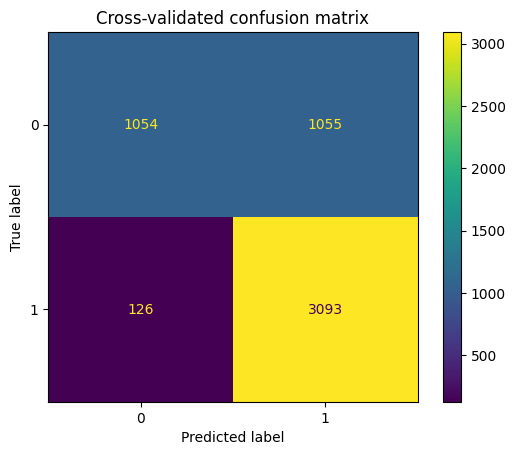

In [27]:
cm = confusion_matrix(y2, y_pred_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Cross-validated confusion matrix')
plt.show()

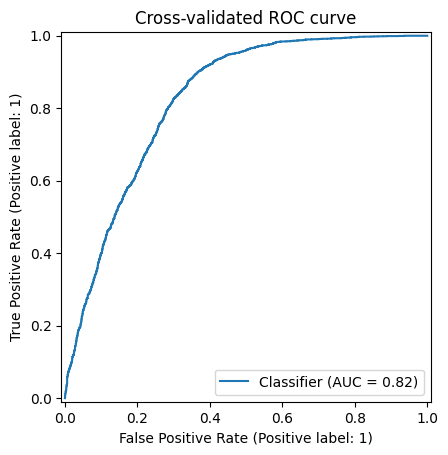

In [28]:
RocCurveDisplay.from_predictions(y2, y_proba_cv)
plt.title('Cross-validated ROC curve')
plt.show()

## 13. Minimal comparison with Logistic Regression

Naive Bayes is **generative** in spirit, while Logistic Regression is **discriminative**. This quick comparison is often very useful in a master-level class.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

logreg_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000)),
])

X_train, X_test, y_train, y_test = train_test_split(
    X2, y2,
    test_size=0.25,
    random_state=42,
    stratify=y2,
)

logreg_model.fit(X_train, y_train)
y_pred_lr = logreg_model.predict(X_test)
y_proba_lr = logreg_model.predict_proba(X_test)[:, 1]

print('Logistic regression accuracy:', accuracy_score(y_test, y_pred_lr))
print('Logistic regression ROC AUC :', roc_auc_score(y_test, y_proba_lr))
print(classification_report(y_test, y_pred_lr, digits=4))

Logistic regression accuracy: 0.8235735735735735
Logistic regression ROC AUC : 0.847907409808243
              precision    recall  f1-score   support

           0     0.8842    0.6376    0.7409       527
           1     0.7994    0.9453    0.8662       805

    accuracy                         0.8236      1332
   macro avg     0.8418    0.7915    0.8036      1332
weighted avg     0.8329    0.8236    0.8167      1332



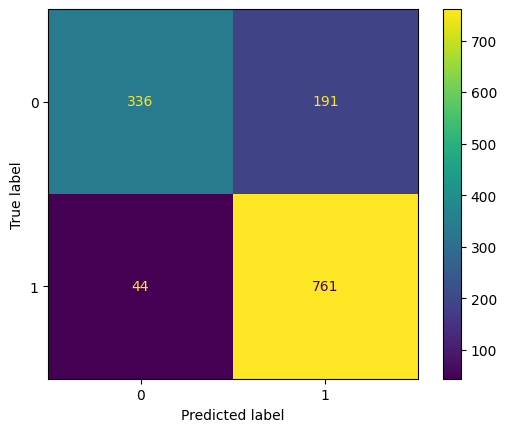

In [32]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot()
plt.show()